# 05 · Model training

**Single responsibility:** train a compact MobileNetV1-style classifier and persist the best checkpoint plus learning curves

Run after the preceding numbered notebook unless the inputs already exist. Every generated artifact is written outside the notebook so this stage is reproducible.


In [1]:
from pathlib import Path
import sys

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'configs/base.yaml').exists())
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

from vww_esp32.config import load_config, resolve_paths, seed_everything

config, ROOT = load_config(ROOT / 'configs/base.yaml')
paths = resolve_paths(config, ROOT)
seed_everything(config['project']['seed'])
ROOT


PosixPath('/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32')

In [2]:
import json
import pandas as pd
import tensorflow as tf
from vww_esp32.preprocessing import make_dataset, split_manifest

manifest = pd.read_csv(paths['processed'] / 'manifest.csv')
splits = split_manifest(manifest)
image_size = tuple(config['preprocessing']['image_size'])
batch_size = config['preprocessing']['batch_size']
train_ds = make_dataset(splits['train'], image_size, batch_size, training=True, seed=config['project']['seed'], cache=config['preprocessing']['cache'])
val_ds = make_dataset(splits['val'], image_size, batch_size, training=False, cache=config['preprocessing']['cache'])
print({name: len(frame) for name, frame in splits.items()})

{'train': 12000, 'val': 2000, 'test': 2000}


In [3]:
from vww_esp32.modeling import build_tiny_mobilenet_v1, compile_model

model = build_tiny_mobilenet_v1(input_shape=(*image_size, 3), alpha=config['model']['width_multiplier'], dropout=config['model']['dropout'], l2=config['model']['l2'])
model = compile_model(model, config['training']['learning_rate'], config['training']['label_smoothing'])
model.summary()
print(f'Parameters: {model.count_params():,}')

Model: "tiny_mobilenet_v1_0.25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalize (Rescaling)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augment_flip (RandomFlip)       │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augment_shift                   │ (None, 96, 96, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_conv (Conv2D)              │ (None, 48, 48, 8)      │           216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_bn (BatchNormalization)    │ (None, 48, 48, 8)      │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stem_relu6 (ReLU)               │ (None, 48, 48, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_dw (DepthwiseConv2D)     │ (None, 48, 48, 8)      │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_dw_bn                    │ (None, 48, 48, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_dw_relu6 (ReLU)          │ (None, 48, 48, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pw (Conv2D)              │ (None, 48, 48, 16)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pw_bn                    │ (None, 48, 48, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pw_relu6 (ReLU)          │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_dw (DepthwiseConv2D)     │ (None, 24, 24, 16)     │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_dw_bn                    │ (None, 24, 24, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_dw_relu6 (ReLU)          │ (None, 24, 24, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pw (Conv2D)              │ (None, 24, 24, 32)     │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pw_bn                    │ (None, 24, 24, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pw_relu6 (ReLU)          │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_dw (DepthwiseConv2D)     │ (None, 24, 24, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_dw_bn                    │ (None, 24, 24, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_dw_relu6 (ReLU)          │ (None, 24, 24, 32)     │             

 Total params: 111,793 (436.69 KB)

 Trainable params: 108,369 (423.32 KB)

 Non-trainable params: 3,424 (13.38 KB)

Parameters: 111,793


In [4]:
from vww_esp32.modeling import training_callbacks

callbacks = training_callbacks(paths['artifacts'], monitor=config['training']['monitor'], patience=config['training']['early_stopping_patience'], lr_patience=config['training']['reduce_lr_patience'])
history = model.fit(train_ds, validation_data=val_ds, epochs=config['training']['epochs'], callbacks=callbacks)

Epoch 1/35
188/188 ━━━━━━━━━━━━━━━━━━━━ 24s 103ms/step - accuracy: 0.5314 - loss: 0.7097 - pr_auc: 0.5342 - precision: 0.5313 - recall: 0.5333 - roc_auc: 0.5398 - val_accuracy: 0.5055 - val_loss: 0.7078 - val_pr_auc: 0.4945 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_roc_auc: 0.5000 - learning_rate: 0.0010
Epoch 2/35
188/188 ━━━━━━━━━━━━━━━━━━━━ 20s 105ms/step - accuracy: 0.5468 - loss: 0.7011 - pr_auc: 0.5544 - precision: 0.5455 - recall: 0.5610 - roc_auc: 0.5685 - val_accuracy: 0.5055 - val_loss: 0.7301 - val_pr_auc: 0.5104 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_roc_auc: 0.5248 - learning_rate: 0.0010
Epoch 3/35
188/188 ━━━━━━━━━━━━━━━━━━━━ 19s 103ms/step - accuracy: 0.5754 - loss: 0.6906 - pr_auc: 0.5849 - precision: 0.5742 - recall: 0.5837 - roc_auc: 0.6025 - val_accuracy: 0.5050 - val_loss: 0.7342 - val_pr_auc: 0.5696 - val_precision: 0.4286 - val_recall: 0.0030 - val_roc_auc: 0.5989 - learning_rate: 0.0010
Epoch 4/35
188/188 ━━━━━━━━━━━━━━━━━━━━

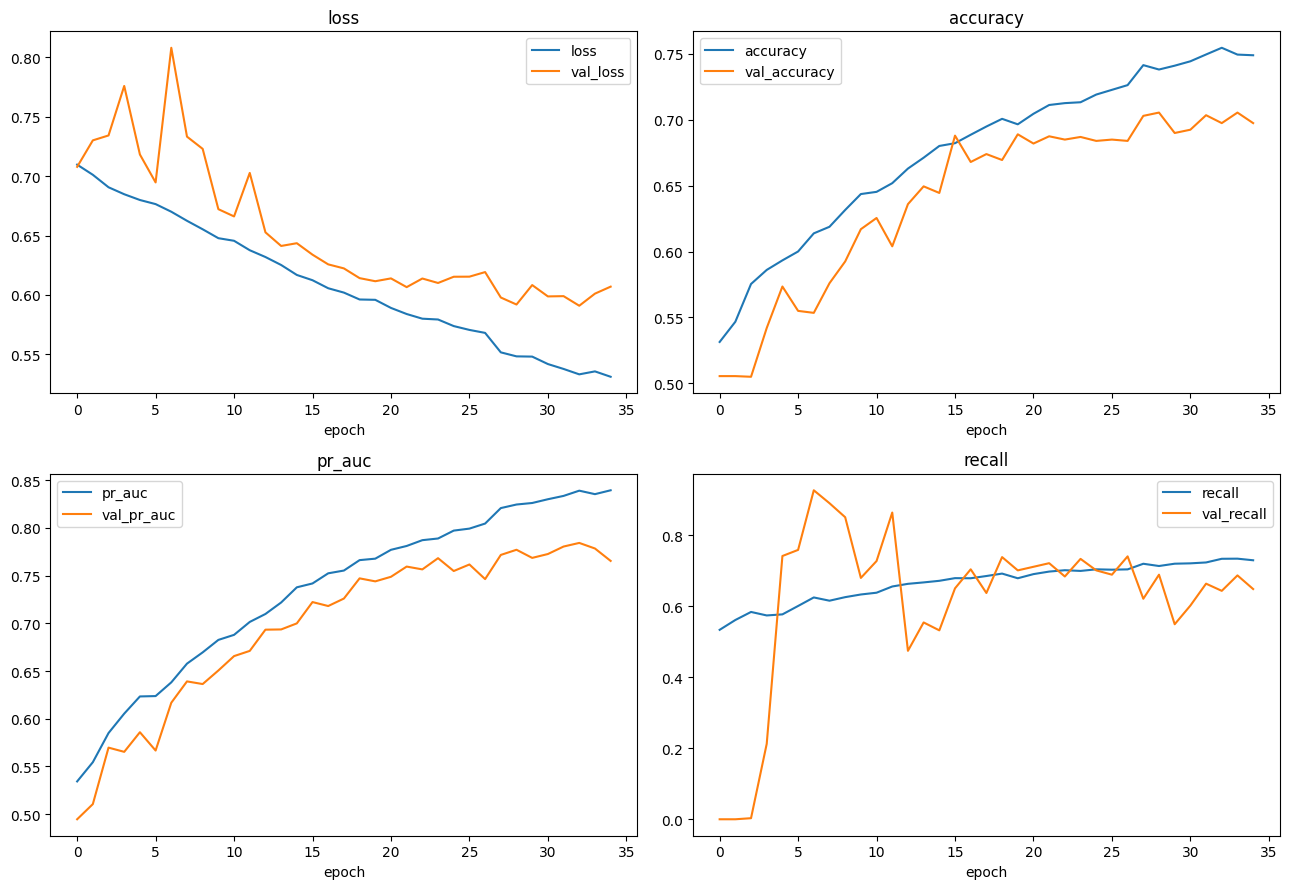

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

history_frame = pd.DataFrame(history.history)
metrics = [('loss', 'val_loss'), ('accuracy', 'val_accuracy'), ('pr_auc', 'val_pr_auc'), ('recall', 'val_recall')]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for axis, pair in zip(axes.flat, metrics):
    history_frame[list(pair)].plot(ax=axis, title=pair[0])
    axis.set_xlabel('epoch')
plt.tight_layout()
figure_path = paths['artifacts'] / 'figures' / 'training_curves.png'
fig.savefig(figure_path, dpi=160, bbox_inches='tight')

In [6]:
final_model = paths['artifacts'] / 'models' / 'final.keras'
model.save(final_model)
metadata = {'seed': config['project']['seed'], 'tensorflow': tf.__version__, 'epochs_completed': len(history_frame), 'best_val_pr_auc': float(history_frame.val_pr_auc.max()), 'parameters': model.count_params()}
(paths['artifacts'] / 'reports' / 'training_metadata.json').write_text(json.dumps(metadata, indent=2))
metadata

{'seed': 42,
 'tensorflow': '2.20.0',
 'epochs_completed': 35,
 'best_val_pr_auc': 0.7843489646911621,
 'parameters': 111793}